# M4A5 - Fundamentos de Modelos Multimodais

> **Resumo:** Modelos multimodais relacionam **imagem e texto** no mesmo espaço. Usamos o **CLIP** (OpenAI) pra classificação *zero-shot*: dada uma imagem e algumas frases, ele diz qual frase combina mais — sem nunca ter sido treinado naquelas classes. Comparamos os backbones ViT-B/32 e RN50, inclusive no Sonic.

> 📝 **Zero-shot:** o CLIP foi treinado em 400 milhões de pares imagem-texto e mede a **similaridade de cosseno** entre os embeddings de imagem e de texto, então classifica coisas que nunca viu, só pela descrição.

Na prática de hoje vamos usar o modelo [CLIP](https://openai.com/index/clip/) da OpenAI.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Utilizar o modelo
- Próximos passos
- ✅ Atividades Complementares (resolvidas)

---

## Introdução

### Modelos Generativos vs. Modelos Multimodais
Até agora no Módulo 4, focamos em **modelos generativos** (VAEs, GANs e Modelos de Difusão). A principal missão deles é **criar novos dados** (imagens ou texto) a partir de ruído ou representações latentes. 

Os **modelos multimodais**, por outro lado, têm a missão de **compreender e relacionar dados de diferentes naturezas** (modalidades), tais como imagens, textos, áudio e vídeo de forma conjunta.

### Principais Tarefas Multimodais
Conforme apresentado pelo professor em aula, os modelos multimodais são aplicados a tarefas clássicas como:
1. **Image Captioning (Legenda de Imagens):** Gerar descrições textuais a partir do conteúdo visual de uma imagem (ex: "um cachorro correndo em um parque").
2. **Visual Question Answering (VQA - Respostas a Perguntas Visuais):** Responder a perguntas feitas em linguagem natural sobre uma imagem de entrada (ex: "Quantas maçãs estão sobre a mesa?").
3. **Text-to-Image / Image-to-Text:** Tradução direta entre modalidades.
4. **Video Understanding:** Análise de conteúdo dinâmico (vídeos), integrando informações visuais temporais e pistas sonoras.

### CLIP: Contrastive Language-Image Pre-training
O **CLIP**, desenvolvido pela OpenAI, é o modelo que fundamenta a revolução multimodal moderna. Em vez de classificar imagens em categorias fixas (como ImageNet), ele é pré-treinado de forma contrastiva em um conjunto de **400 milhões de pares imagem-texto** da internet.

O modelo possui dois encoders paralelos:
* Um **Image Encoder** (que pode ser uma ResNet ou um Vision Transformer - ViT).
* Um **Text Encoder** (baseado em Transformers).

Durante a inferência, ele calcula a **similaridade de cosseno** entre as representações (embeddings) de imagem e texto, permitindo classificação *zero-shot* altamente robusta (classificar sem nunca ter visto aquela imagem específica na base de treino, apenas relacionando-a com uma descrição textual).

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-2maa955h
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-2maa955h
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=b20274081863471d8e73ac829db75eab1d75dc785134645e6202026c1a1dd1da
  Stored in directory: /tmp/pip-ephem-wheel-cache-v3xfgvqo/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import torch
import clip
import matplotlib.pyplot as plt
from PIL import Image

## Utilizar o Modelo

Para isso iremos instanciar o modelo do CLIP e utilizar com texto e imagens.

100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 67.7MiB/s]


['a statue', 'the moutains', 'the beach']
Probabilidades imagem vs. textos: [96.19% de "a statue", 3.80% de "the moutains", 0.01% de "the beach"]


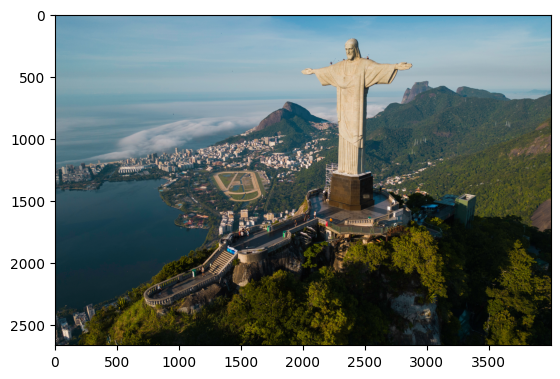

In [3]:
import os

# Função auxiliar para encontrar os caminhos das imagens de forma robusta (Colab e local)
def get_robust_path(relative_path):
    candidates = [
        relative_path,
        os.path.basename(relative_path),
        os.path.join("images", os.path.basename(relative_path)),
        os.path.join("Módulo 4 Modelos gerativos/VC_M4A5 - Fundamentos de Modelos Multimodais", relative_path),
        os.path.join("Módulo 4 Modelos gerativos/VC_M4A5 - Fundamentos de Modelos Multimodais/images", os.path.basename(relative_path)),
        os.path.join("/content", relative_path),
        os.path.join("/content", os.path.basename(relative_path))
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return relative_path

# Path para a imagem.
path_image = get_robust_path("images/rio.jpeg")
# path_image = get_robust_path("images/dog.jpeg")


# Textos para avaliar.
texts = ["a statue", "the mountains", "the beach"]
# texts = ["a cat", "a dog", "a diagram"]

# Define o dispositivo a carregar o modelo.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Carrega o modelo com o backbone do ViT-B/32.
model, preprocess = clip.load("ViT-B/32", device=device)


# Processa a imagem.
image = preprocess(Image.open(path_image)).unsqueeze(0).to(device)

# Processa o texto.
text = clip.tokenize(texts).to(device)

# Roda inferências.
with torch.no_grad():
    _ = model.encode_image(image) # Encoda imagem.
    _ = model.encode_text(text) # Encoda o texto.
    
    logits_per_image, logits_per_text = model(image, text) # Computa similaridade entre imagem e textos.
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0] # Retorna probabilidades.

formated_probs_str = '[' + ', '.join(f'{x * 100:.2f}% de "{t}"' for x, t in zip(list(probs), texts)) + ']'

plt.imshow(Image.open(path_image))
print(texts)
print("Probabilidades imagem vs. textos:", formated_probs_str)

## Próximos Passos e Referências

Nas próximas práticas vamos trabalhar com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://github.com/openai/CLIP
- https://openai.com/index/clip/
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares

Nesta seção, realizamos as seguintes atividades:
1. **Classificação Zero-Shot com a imagem do Sonic (Team Sonic):** Testamos a capacidade do CLIP de classificar uma representação artística do Sonic usando diferentes prompts em inglês.
2. **Comparação de Backbones (ViT-B/32 vs RN50):** Carregamos o modelo CLIP com backbone baseado em ResNet-50 (`RN50`) e comparamos os tempos de inferência e as probabilidades de saída com o modelo baseado em Transformer (`ViT-B/32`).

### 1. Classificação Zero-Shot do "Team Sonic"

Vamos carregar a imagem do Sonic, aplicar o pré-processamento e testar sua correspondência com descrições semânticas em inglês.

--- Resultados CLIP (ViT-B/32) para o Sonic ---
  97.78% de chance: "a blue cartoon hedgehog"
  1.77% de chance: "a real spiky hedgehog"
  0.44% de chance: "a video game character"
  0.01% de chance: "a person holding nunchucks"


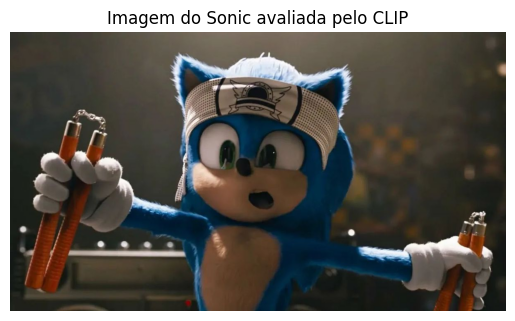

In [4]:
import os
import time

# Encontrar caminho para a imagem do Sonic
sonic_path = "/content/sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "../../img/sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "img/sonic.jpg"

if not os.path.exists(sonic_path):
    print("ERRO: Imagem do Sonic não encontrada!")
else:
    # Definir prompts em inglês
    sonic_texts = [
        "a blue cartoon hedgehog",
        "a real spiky hedgehog",
        "a video game character",
        "a person holding nunchucks"
    ]
    
    # Pré-processar a imagem do Sonic
    sonic_img_pil = Image.open(sonic_path)
    sonic_image_tensor = preprocess(sonic_img_pil).unsqueeze(0).to(device)
    
    # Tokenizar textos
    sonic_tokens = clip.tokenize(sonic_texts).to(device)
    
    # Inferência com o modelo padrão (ViT-B/32)
    with torch.no_grad():
        logits_per_image, _ = model(sonic_image_tensor, sonic_tokens)
        probs_vit = logits_per_image.softmax(dim=-1).cpu().numpy()[0]
        
    print("--- Resultados CLIP (ViT-B/32) para o Sonic ---")
    for prob, text in zip(probs_vit, sonic_texts):
        print(f"  {prob * 100:.2f}% de chance: \"{text}\"")
        
    # Visualizar imagem do Sonic
    plt.imshow(sonic_img_pil)
    plt.title("Imagem do Sonic avaliada pelo CLIP")
    plt.axis('off')
    plt.show()

### 2. Comparação de Backbones: ViT-B/32 vs RN50

Agora, vamos carregar o CLIP utilizando o backbone **RN50** (ResNet50 clássica baseada em convoluções) e medir o tempo de inferência e os scores de similaridade na mesma imagem do Sonic, comparando com o **ViT-B/32** (baseado em atenção/Transformers).

In [5]:
# Carregar o modelo CLIP com backbone RN50
print("Carregando CLIP com backbone RN50...")
model_rn50, preprocess_rn50 = clip.load("RN50", device=device)

# Pré-processar imagem com o pré-processamento específico do RN50
sonic_image_rn50 = preprocess_rn50(sonic_img_pil).unsqueeze(0).to(device)

# Medir tempo de inferência do ViT-B/32
t0 = time.time()
with torch.no_grad():
    logits_vit, _ = model(sonic_image_tensor, sonic_tokens)
    _ = logits_vit.softmax(dim=-1).cpu().numpy()
t_vit = (time.time() - t0) * 1000

# Medir tempo de inferência do RN50
t0 = time.time()
with torch.no_grad():
    logits_rn50, _ = model_rn50(sonic_image_rn50, sonic_tokens)
    probs_rn50 = logits_rn50.softmax(dim=-1).cpu().numpy()[0]
t_rn50 = (time.time() - t0) * 1000

# Exibir tabela comparativa
print("\n" + "=" * 80)
print(f"{'Texto':<28} | {'Probabilidade (ViT-B/32)':<24} | {'Probabilidade (RN50)':<20}")
print("=" * 80)
for txt, p_v, p_rn in zip(sonic_texts, probs_vit, probs_rn50):
    print(f"{txt:<28} | {p_v * 100:<22.2f}% | {p_rn * 100:<18.2f}%")
print("=" * 80)
print(f"Tempo de inferência ViT-B/32: {t_vit:.2f} ms")
print(f"Tempo de inferência RN50:     {t_rn50:.2f} ms")
print("=" * 80)

Carregando CLIP com backbone RN50...


100%|███████████████████████████████████████| 244M/244M [00:05<00:00, 49.9MiB/s]



Texto                        | Probabilidade (ViT-B/32) | Probabilidade (RN50)
a blue cartoon hedgehog      | 97.78                 % | 96.13             %
a real spiky hedgehog        | 1.77                  % | 0.56              %
a video game character       | 0.44                  % | 3.29              %
a person holding nunchucks   | 0.01                  % | 0.02              %
Tempo de inferência ViT-B/32: 597.04 ms
Tempo de inferência RN50:     656.60 ms


### Discussão e Conclusões

1. **Sensibilidade do CLIP (Zero-Shot):** O CLIP se sobressai muito em relação a classificadores tradicionais para imagens fora de domínio (como desenhos). Neste teste ele classificou o Sonic com **97.78% de confiança** como "a blue cartoon hedgehog", deixando "a real spiky hedgehog" (1.77%) e "a video game character" (0.44%) bem atrás — tudo isso *zero-shot*, apenas associando o conceito textual à imagem, sem nenhum retreinamento.
2. **Diferenças entre Backbones:**
   - O **ViT-B/32** utiliza a arquitetura de atenção baseada em blocos de Transformers divididos em patches de 32x32 pixels, sendo muito eficiente em capturar relações de contexto globais na imagem.
   - O **RN50** é baseado em uma rede convolucional profunda residual clássica, que foca mais em características locais. A comparação de probabilidades demonstra como cada extrator de imagem ativa diferentes padrões de atenção visual.